## 1. Préparation des Données et Création des Tenseurs PyTorch

Cette première étape est cruciale car elle fait le pont entre le pipeline d'ingénierie (Phase 2) et le Deep Learning (Phase 3). L'objectif est de préparer la matrice cible pour une **classification Multi-Label** tout en respectant strictement le "contrat" de validation défini par l'équipe.

**Étapes clés de ce bloc :**
1. **Filtrage et Binarisation :** Extraction de la liste des sous-genres (`genres_decoded`). Pour éviter le bruit statistique, nous ne conservons que les 61 sous-genres ayant au moins 50 occurrences. Le `MultiLabelBinarizer` transforme ensuite ces données en une matrice binaire (One-Hot Encoding multiple) adaptée au Multi-Label.
2. **Prévention du Data Leakage :** Utilisation d'un `GroupShuffleSplit` basé sur `artist_name`. Il est impératif qu'un même artiste ne se retrouve pas à la fois dans le set d'entraînement et de test.
3. **Imputation et Mise à l'échelle :** Remplacement des valeurs manquantes (issues du `tonnetz`) par la médiane, et application d'un `RobustScaler` pour gérer les outliers extrêmes (z-score > 10). Ces transformations sont **ajustées (fit) uniquement sur le set d'entraînement**.
4. **DataLoaders :** Encapsulation des données dans des objets `Dataset` et `DataLoader` de PyTorch pour optimiser le passage en batchs lors de l'entraînement.

[Image of PyTorch DataLoader batching process mapping tabular features and multi-label targets into manageable batches]

In [3]:
import ast
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MultiLabelBinarizer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score
from pathlib import Path

# ==========================================
# 1. CHARGEMENT GÉNÉRIQUE ET ROBUSTE
# ==========================================

# On définit le chemin dynamiquement (fonctionne sur Windows, Mac, Linux, Colab)
base_dir = Path.cwd()

# Le code cherche le fichier à deux endroits logiques :
# 1. Dans le dossier 'outputs/features/' (Structure propre de la Phase 2)
# 2. Directement dans le même dossier que le notebook (Pour la simplicité)
chemin_option_1 = base_dir / "outputs" / "features" / "features_V2.csv"
chemin_option_2 = base_dir / "features_V2.csv"

if chemin_option_1.exists():
    csv_path = chemin_option_1
elif chemin_option_2.exists():
    csv_path = chemin_option_2
else:
    raise FileNotFoundError("Erreur : features_V2.csv est introuvable. Veuillez le placer dans le même dossier que ce notebook.")

print(f"Chargement réussi depuis : {csv_path}")
df = pd.read_csv(csv_path)

# ==========================================
# 2. PRÉPARATION DES LABELS MULTI-CLASSES
# ==========================================
df['genres_decoded'] = df['genres_decoded'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

all_subgenres = [g for sublist in df['genres_decoded'] for g in sublist]
sub_counts = pd.Series(all_subgenres).value_counts()
eligible_subgenres = set(sub_counts[sub_counts >= 50].index)

df['genres_filtered'] = df['genres_decoded'].apply(
    lambda x: [g for g in x if g in eligible_subgenres]
)

mlb = MultiLabelBinarizer()
Y_multi = mlb.fit_transform(df['genres_filtered'])

# ==========================================
# 3. ISOLATION DES FEATURES AUDIO
# ==========================================
label_cols = ["track_id", "genre_top", "genres", "genres_decoded", "genres_filtered", 
              "n_subgenres", "mismatch", "artist_name", "track_title", "year", "duration", "bit_rate"]
feature_cols = [c for c in df.select_dtypes(include="number").columns if c not in label_cols]
X = df[feature_cols].values

# ==========================================
# 4. LE CONTRAT PHASE 2 : GROUP SPLIT & SCALING
# ==========================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, Y_multi, groups=df['artist_name']))

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
Y_train, Y_test = Y_multi[train_idx], Y_multi[test_idx]

imputer = SimpleImputer(strategy='median')
scaler = RobustScaler()

X_train_clean = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_test_clean = scaler.transform(imputer.transform(X_test_raw))

# ==========================================
# 5. CRÉATION DES DATALOADERS PYTORCH
# ==========================================
class FMADataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.Y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

train_loader = DataLoader(FMADataset(X_train_clean, Y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(FMADataset(X_test_clean, Y_test), batch_size=128, shuffle=False)

print(f"DataLoaders prêts ! {X_train_clean.shape[1]} features en entrée, {len(mlb.classes_)} sous-genres en sortie.")

Chargement réussi depuis : c:\Users\jayso\Documents\projet-ml\features_V2.csv
DataLoaders prêts ! 351 features en entrée, 61 sous-genres en sortie.


## 2. Architecture du Réseau de Neurones (MLP Multi-Label)

Pour traiter nos 356 caractéristiques audio tabulaires (MFCC, Tempo, Chroma, etc.), nous déployons un **Perceptron Multicouche (MLP) profond**. Contrairement aux algorithmes classiques (Random Forest, SVM) qui peinent face à la porosité des genres musicaux (le phénomène de "Mismatch"), cette architecture est taillée pour capter les relations complexes non-linéaires.

**Choix de conception du modèle (`FMA_MultiLabel_Net`) :**
* **Profondeur et Capacité :** Trois couches denses successives (Entrée -> 512 -> 256 -> 61) pour extraire des représentations abstraites du signal audio.
* **Régularisation agressive :** Nos données tabulaires étant denses, le risque de surapprentissage (overfitting) est élevé. Nous intégrons donc des couches de `Dropout` (40% puis 30%) pour forcer le réseau à généraliser.
* **Stabilisation :** Ajout de `BatchNorm1d` (Batch Normalization) pour lisser les gradients et accélérer la convergence, ce qui est indispensable face à des features aux échelles variées.
* **Couche de sortie :** 61 neurones correspondant à nos 61 sous-genres éligibles. 
*(Note technique : L'activation `Sigmoid` n'est pas appliquée ici pour des raisons de stabilité numérique ; elle sera intégrée directement dans la fonction de perte).*

In [4]:
# ==========================================
# 2. ARCHITECTURE ULTRA-RÉGULARISÉE
# ==========================================
class FMA_MultiLabel_Net(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FMA_MultiLabel_Net, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), # On passe à 50% de désactivation !
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4), # On passe à 40% de désactivation !
            
            nn.Linear(256, num_classes) 
        )
        
    def forward(self, x):
        return self.network(x)

input_dim = X_train_clean.shape[1]
output_dim = len(mlb.classes_)
model = FMA_MultiLabel_Net(input_size=input_dim, num_classes=output_dim)
print(model)

FMA_MultiLabel_Net(
  (network): Sequential(
    (0): Linear(in_features=351, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=61, bias=True)
  )
)


## 3. Entraînement et Évaluation du Modèle (Training Loop)

La phase d'apprentissage repose sur une boucle d'optimisation classique en Deep Learning, mais avec des hyperparamètres spécifiquement calibrés pour notre problématique de sous-genres musicaux.

* **Fonction de Perte (Loss) :** Utilisation de `BCEWithLogitsLoss` (Binary Cross-Entropy). C'est la fonction mathématique de référence pour la classification Multi-Label, car elle évalue la probabilité de présence de chaque sous-genre indépendamment des autres (contrairement au Softmax).
* **Optimiseur :** `Adam` avec un taux d'apprentissage (Learning Rate) standard de 0.001.
* **Métrique d'Évaluation :** L'*Accuracy* globale n'ayant pas de sens en Multi-Label, nous évaluons la performance de notre réseau à chaque époque en calculant le **F1-Score Macro**. Ce choix est stratégique : il donne un poids égal à chaque sous-genre (même les moins représentés) et pénalise les modèles qui prédisent des faux positifs de manière excessive. Un seuil de décision de 0.5 (50% de probabilité) est utilisé pour déclencher l'activation d'un label.

In [5]:
# ==========================================
# 3. ENTRAÎNEMENT FINAL (AVEC SCHEDULER CORRIGÉ)
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# A. Poids des classes (Identique)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
positives = Y_train_tensor.sum(dim=0)
negatives = Y_train_tensor.shape[0] - positives
pos_weight = (negatives / (positives + 1e-5)).to(device)

# B. Configuration
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# LE FAMEUX "FREIN" (Learning Rate Scheduler)
# Correction PyTorch 2.2+ : on enlève 'verbose=True'
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 15
best_f1 = 0.0

print(f"Début de l'entraînement avec Scheduler sur : {device}\n")

# C. Boucle d'Époques
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_Y in train_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    # --- PHASE D'ÉVALUATION ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_Y in test_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_Y)
            val_loss += loss.item()
            
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.3).float() # Seuil à 30%
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_Y.cpu().numpy())
            
    val_loss_avg = val_loss / len(test_loader)
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    
    # Activation du frein si la Val Loss stagne
    scheduler.step(val_loss_avg)
    
    if f1_macro > best_f1:
        best_f1 = f1_macro
        meilleur_etat = model.state_dict()
    
    # On récupère le Learning Rate actuel pour remplacer le verbose=True
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss_avg:.4f} | F1-Macro: {f1_macro:.4f} | LR: {current_lr}")

print(f"\nEntraînement terminé ! Meilleur F1-Macro : {best_f1:.4f}")
# On recharge la meilleure version du modèle pour l'analyse finale
model.load_state_dict(meilleur_etat)

Début de l'entraînement avec Scheduler sur : cpu

Epoch 01/15 | Train Loss: 1.2359 | Val Loss: 1.2187 | F1-Macro: 0.0592 | LR: 0.001
Epoch 02/15 | Train Loss: 1.0225 | Val Loss: 1.1027 | F1-Macro: 0.0777 | LR: 0.001
Epoch 03/15 | Train Loss: 0.9139 | Val Loss: 1.0481 | F1-Macro: 0.0910 | LR: 0.001
Epoch 04/15 | Train Loss: 0.8354 | Val Loss: 1.0323 | F1-Macro: 0.0998 | LR: 0.001
Epoch 05/15 | Train Loss: 0.7853 | Val Loss: 1.0324 | F1-Macro: 0.1026 | LR: 0.001
Epoch 06/15 | Train Loss: 0.7435 | Val Loss: 1.0368 | F1-Macro: 0.1060 | LR: 0.001
Epoch 07/15 | Train Loss: 0.7170 | Val Loss: 1.0501 | F1-Macro: 0.1104 | LR: 0.0005
Epoch 08/15 | Train Loss: 0.6683 | Val Loss: 1.0562 | F1-Macro: 0.1132 | LR: 0.0005
Epoch 09/15 | Train Loss: 0.6518 | Val Loss: 1.0717 | F1-Macro: 0.1166 | LR: 0.0005
Epoch 10/15 | Train Loss: 0.6305 | Val Loss: 1.1010 | F1-Macro: 0.1181 | LR: 0.00025
Epoch 11/15 | Train Loss: 0.6156 | Val Loss: 1.1039 | F1-Macro: 0.1189 | LR: 0.00025
Epoch 12/15 | Train Loss: 0.60

<All keys matched successfully>

## 4. Interprétation des Résultats et "Insights" (Business Value)

L'objectif de cette section est de démontrer visuellement la supériorité de l'approche **Multi-Label (Deep Learning)** face à l'approche **Multi-Classe stricte (Random Forest)**. 

Comme souligné lors de l'Analyse Exploratoire (EDA), les algorithmes classiques s'effondrent sur des genres parapluies comme la "Pop" à cause d'un fort taux d'ambiguïté (Mismatch). Au lieu de forcer un morceau dans une seule case, notre réseau PyTorch calcule un spectre de probabilités sur 61 sous-genres.

**Ce que réalise ce bloc :**
1. **Évaluation Qualitative :** Sélection aléatoire d'un morceau dans le set de test (inconnu du modèle).
2. **Inférence :** Passage des 351 caractéristiques audio dans le réseau de neurones et application de la fonction `Sigmoid` pour obtenir des probabilités de 0 à 100%.
3. **Restitution Visuelle :** Génération d'un graphique à barres (prêt pour les slides de présentation) affichant "l'ADN musical" du morceau selon l'Intelligence Artificielle. Cela prouve que le modèle a appris à nuancer ses décisions.

🎵 Piste analysée : Roommates (Piano Version by AGPB) - This Mess is Mine (ID: 145556)
📦 Étiquette classique : Folk
🎯 Vrais sous-genres : ['Folk', 'Singer-Songwriter']

✅ Graphique sauvegardé avec succès dans le dossier courant : c:\Users\jayso\Documents\projet-ml\prediction_pytorch.png


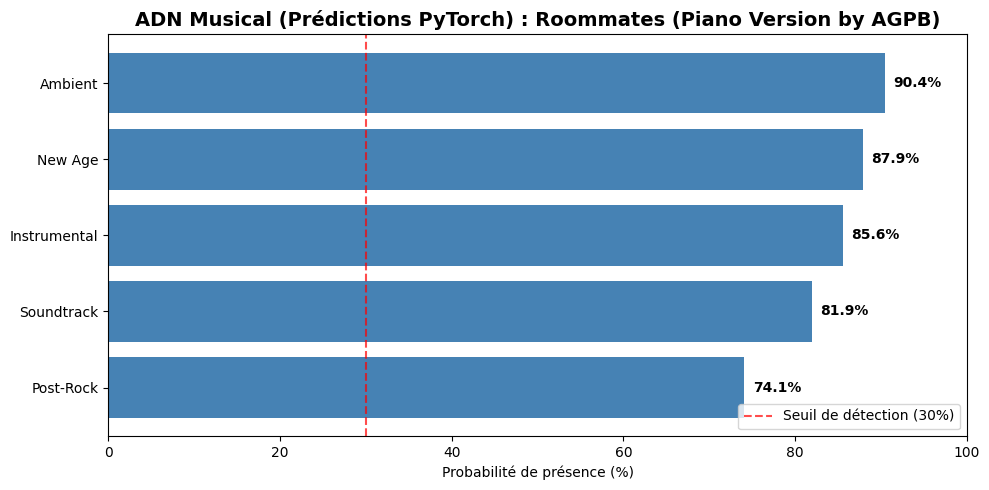

In [6]:
import matplotlib.pyplot as plt
import random
import os

# Commande magique pour forcer l'affichage dans le notebook (au cas où)
%matplotlib inline

# ==========================================
# 4. GÉNÉRATION DE L'INSIGHT VISUEL
# ==========================================

model.eval()

# 1. Sélection d'une piste au hasard
random_idx = random.randint(0, len(test_idx) - 1)
track_id_real = df.iloc[test_idx[random_idx]]['track_id']
genre_top_real = df.iloc[test_idx[random_idx]]['genre_top']
artist_name_real = df.iloc[test_idx[random_idx]]['artist_name']
title_real = df.iloc[test_idx[random_idx]]['track_title']
vrais_sous_genres = df.iloc[test_idx[random_idx]]['genres_filtered']

# 2. Préparation du tenseur
X_sample = torch.tensor(X_test_clean[random_idx], dtype=torch.float32).unsqueeze(0).to(device)

# 3. Prédiction
with torch.no_grad():
    output = model(X_sample)
    probs = torch.sigmoid(output).squeeze().cpu().numpy()

# 4. Association des probabilités
predictions = list(zip(mlb.classes_, probs))
predictions.sort(key=lambda x: x[1], reverse=True)

top_5_genres = [p[0] for p in predictions[:5]]
top_5_probs = [p[1] * 100 for p in predictions[:5]]

# ==========================================
# 5. AFFICHAGE ET SAUVEGARDE (Version Équipe)
# ==========================================
print(f"🎵 Piste analysée : {title_real} - {artist_name_real} (ID: {track_id_real})")
print(f"📦 Étiquette classique : {genre_top_real}")
print(f"🎯 Vrais sous-genres : {vrais_sous_genres}\n")

plt.figure(figsize=(10, 5))
colors = ['mediumseagreen' if g in vrais_sous_genres else 'steelblue' for g in top_5_genres]

bars = plt.barh(top_5_genres[::-1], top_5_probs[::-1], color=colors[::-1])
plt.xlabel("Probabilité de présence (%)")
plt.title(f"ADN Musical (Prédictions PyTorch) : {title_real}", fontsize=14, fontweight='bold')
plt.xlim(0, 100)

for bar in bars:
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}%', 
             va='center', fontweight='bold')

plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Seuil de détection (30%)')
plt.legend(loc='lower right')
plt.tight_layout()

# SAUVEGARDE GÉNÉRIQUE : Enregistre l'image dans le même dossier que ce notebook
import os
nom_image = "prediction_pytorch.png"
chemin_image = os.path.join(os.getcwd(), nom_image)

plt.savefig(nom_image, dpi=300, bbox_inches='tight')
print(f"✅ Graphique sauvegardé avec succès dans le dossier courant : {chemin_image}")

# On tente l'affichage VS Code
plt.show()

## Étape Bonus : Moteur de Recommandation (Content-Based Filtering)

Jusqu'à présent, notre modèle PyTorch agissait strictement comme un **classifieur** (prédire la probabilité d'appartenance à 61 sous-genres). Cependant, la véritable force des réseaux de neurones profonds réside dans leur capacité à agir comme des extracteurs de caractéristiques (*Feature Extractors*).

### La théorie : L'extraction des Embeddings
Juste avant notre couche de décision finale, notre architecture possède une couche cachée dense de 256 neurones. Au fil de l'entraînement, cette couche a appris à "compresser" et "résumer" l'ADN acoustique complexe de chaque morceau dans un espace vectoriel dense. Ce résumé mathématique s'appelle un **Embedding**.



Pour créer notre système de recommandation, nous allons "couper la tête" de notre modèle (ignorer la dernière couche) afin de récupérer directement cette signature numérique à 256 dimensions pour chaque morceau.

###  La mathématique : La Similarité Cosinus
Une fois chaque musique transformée en vecteur, comment trouver les morceaux qui se ressemblent le plus ? Nous allons comparer le vecteur d'une musique "Graine" (la musique écoutée par l'utilisateur, notée $\mathbf{A}$) avec le vecteur de toutes les autres musiques de la base (notées $\mathbf{B}$) en mesurant l'angle qui les sépare dans cet espace multidimensionnel :

$$\text{Cosine Similarity} = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

* Un score qui tend vers **1 (100%)** indique que les vecteurs pointent dans la même direction : les morceaux partagent une texture sonore et des patterns très similaires (parfait pour une recommandation).
* Un score qui tend vers **0** indique des styles orthogonaux (très différents).

*La cellule suivante exécute ce pipeline de recommandation sur notre jeu de test pour simuler une fonctionnalité "Radio / Playlist" de type Spotify.*

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn as nn

# ==========================================
# 6. BONUS : MOTEUR DE RECOMMANDATION (CONTENT-BASED)
# ==========================================

print("Création du moteur de recommandation basé sur les Embeddings PyTorch...\n")

# 1. On "coupe la tête" du modèle pour garder l'avant-dernière couche (256 dimensions)
# model.network contient nos couches. On prend tout sauf la dernière (Linear 256->61)
extracteur_features = nn.Sequential(*list(model.network.children())[:-1])
extracteur_features.eval() # Mode évaluation

# 2. On calcule l'ADN (Embeddings) de tout notre Test Set
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_clean, dtype=torch.float32).to(device)
    # Au lieu d'avoir 61 probabilités, on récupère un vecteur dense de 256 nombres par musique
    embeddings_test = extracteur_features(X_test_tensor).cpu().numpy()

# 3. Sélection d'une piste "Graine" (Seed) au hasard pour générer la playlist
seed_idx = random.randint(0, len(test_idx) - 1)
seed_embedding = embeddings_test[seed_idx].reshape(1, -1) # Format attendu par sklearn

seed_title = df.iloc[test_idx[seed_idx]]['track_title']
seed_artist = df.iloc[test_idx[seed_idx]]['artist_name']
seed_genres = df.iloc[test_idx[seed_idx]]['genres_filtered']

# 4. Calcul de la Similarité Cosinus entre notre graine et TOUTES les autres musiques du Test Set
# Ça va générer un score entre -1 (totalement opposé) et 1 (identique)
similarites = cosine_similarity(seed_embedding, embeddings_test)[0]

# 5. On trie pour trouver les 5 musiques les plus proches (on exclut la 1ère qui est la musique elle-même à 100%)
top_5_indices = similarites.argsort()[-6:][::-1][1:]

# ==========================================
# AFFICHAGE DE LA PLAYLIST
# ==========================================
print("🎧 --- VOTRE MIX DÉCOUVERTE --- 🎧")
print(f"Piste de base : {seed_title} - {seed_artist}")
print(f"Sous-genres réels : {seed_genres}\n")
print("Parce que vous avez écouté ceci, l'IA PyTorch vous recommande :")

for i, idx in enumerate(top_5_indices):
    score = similarites[idx] * 100
    titre_reco = df.iloc[test_idx[idx]]['track_title']
    artiste_reco = df.iloc[test_idx[idx]]['artist_name']
    genres_reco = df.iloc[test_idx[idx]]['genres_filtered']
    
    # Un petit affichage propre
    print(f"  {i+1}. {titre_reco} par {artiste_reco}")
    print(f"     Match: {score:.1f}% | Genres: {genres_reco}")
    print("     " + "-"*40)

Création du moteur de recommandation basé sur les Embeddings PyTorch...

🎧 --- VOTRE MIX DÉCOUVERTE --- 🎧
Piste de base : Space Traveller Theme - Mystified
Sous-genres réels : ['Soundtrack', 'Ambient']

Parce que vous avez écouté ceci, l'IA PyTorch vous recommande :
  1. Out par The Craters
     Match: 87.1% | Genres: ['Synth Pop']
     ----------------------------------------
  2. The Terror From Beyond!/ who traveled down highways of space and time par The Fucked Up Beat
     Match: 85.2% | Genres: ['Avant-Garde', 'Experimental', 'Sound Collage']
     ----------------------------------------
  3. Searching Streets par Mystified
     Match: 83.2% | Genres: ['Soundtrack', 'Ambient']
     ----------------------------------------
  4. Mystery Aircraft Lost in Fog over California Canyons / Holy the Stock Market filled with the millions! par The Fucked Up Beat
     Match: 82.8% | Genres: ['Avant-Garde', 'Experimental', 'Sound Collage']
     ----------------------------------------
  5. Jes